In [45]:
import panel as pn
pn.extension()

# Programmieren einer Simulation unseres Sonnensystems
---

1. Idee
2. Theorie
3. Tools

## Idee
---



2D-Modell unseres Sonnensystems nach *Newtons Gravitationsgesetz*

**Ziel: Basis lernen, um später komplexere Simulationen realisieren zu können.**

Dazu habe ich nach einem Tutorial gearbeitet.

In [13]:
from IPython.display import IFrame
IFrame(src="https://www.youtube.com/embed/WTLPmUHTPqo?si=fmQQKo_2Txp6xPnf", width="560", height="315")

## Theorie

### Simulation

Die **Realität** unseres Sonnensystems ist eigentlich sehr **komplex**. \
Um eine **Simulation** zu schreiben, muss das Problem erst **vereinfacht** werden. 

**&rarr;** **Modell**

### Newtons Graviationsgesetz

Die **dreidimensionalen Körper** unseres Sonnensystems lassen sich in einem **zweidimensionalen Koordinatensystem** als **Massenpunkte** beschreiben. Es gibt einen Abstand $r$ und einen Winkel $\vartheta$ zwischen ihnen.  

**Newtons Gravitationsgesetz** beschreibt die **Wechselwirkung zwischen zwei Massen**, wobei $F$ die resultierende Kraft ist und $G$ die Gravitationskonstante. $m_1$ und $m_2$ sind die Punktmassen der beiden Körper, und *r* der Abstand.

$$ F = G \frac{m_1 m_2}{r^2} $$

### Koordinatensystem

Da wir uns mit Positionen von Objekten außereinandersetzen müssen, müssen wir ein Koordinatensystem definieren. \
Ein Koordinatensystem mit **horizontalen** und **vertikalen** Positionen, also **x- und y-Richtung**, nennt man **Kartesisches Koordinatensystem**.

Der **Abstand $r$** kann als **Funktion der Position des Körpers** in Kartesischen Koordinaten folgendermaßen beschrieben werden:
$$ r = \sqrt{(x_1-x_2)^2+(y_1-y_2)^2}$$

## Umsetzung

### Berechnung der Anziehungskräfte

Da es mehr als zwei Körper in unserem Sonnensystem gibt, muss die **Kraft zwischen Sonne und Planeten** für jeden Planeten ausgerechnet werden. Man muss das Prinzip nach der die Rechnung erfolgt, nur ein mal definieren und begriffen haben.

**Leitfrage I** : **Wie setzen sich die Kräfte zusammen?**

**Kraft in x-Richtung**: $ F_x = cos(\vartheta)F $ \
**Kraft in y-Richtung**: $ F_y = cos(\vartheta)F $ 

$F_{GESAMT} = F_x + F_y $ 

**Leitfrage II:** **Wie legen wir unser Koordinatensystem, um die Rechnung möglichst einfach zu gestalten?**

**Die Sonne wird in den Mittelpunkt des Koordinatensystems gelegt (y = 0, x = 0).**
Auch das ist eine Vereinfachung. Denn die Sonne hat keine feste absolute Position. Sie ist durch die Kräfte anderer astronomischer Objekte in unserer Milchstraße immer in Bewegung. Ihre Position ist in der Realität immer nur relativ beschreibbar.

**Die Startposition der Planeten in vertikaler (y-Richtung) soll 0 sein**, damit ist $ F_{START} $ nur von einer Richtung abhängig und $r$ entspricht dem Abstand zwischen Planeten und Sonne den man aus Beobachtung/Messung erhält. 

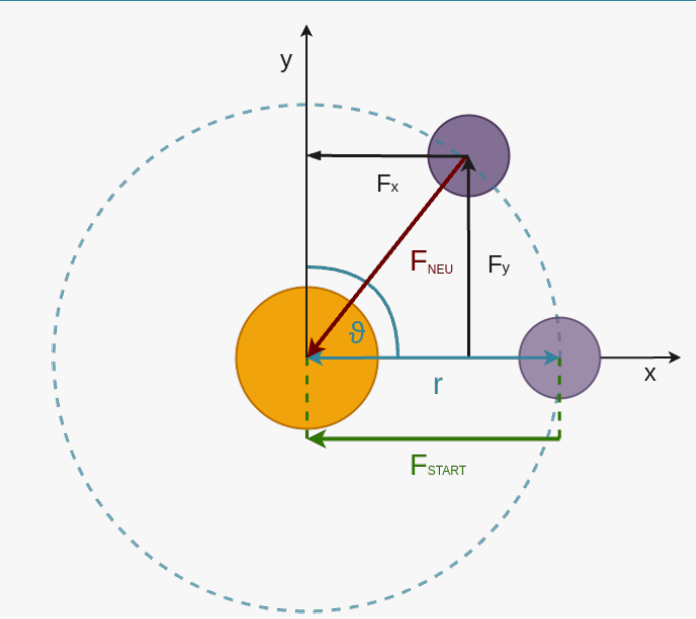

In [28]:
from IPython.display import Image
Image("illustration.png")

### Abstände der Planeten zur Sonne

**Leitfrage III:** **Wie sind denn die von Teleskopen gemessenen Abstände zur Sonne?**

Auch hier muss man eine Entscheidung treffen, was die Simulation darstellen soll. Denn die Planeten bewegen sich ständig und haben eigentlich keine feste Position. \
Man kann vom **Mittleren Abstand** der Planeten zur Sonne starten, man kann vom **nächsten Punkt (Perihelion)** zur Sonne oder vom **weitesten Punkt (Aphelion)** zur Sonne starten.

Daten von [NASA](https://nssdc.gsfc.nasa.gov/planetary/factsheet/), Abstandsangaben in $10^6$ Kilometer:
| Planet | Mittlerer Abstand | Perihelion | Aphelion |
|--|--|--|--|
| Merkur  | 57.9   | 46.0   | 69.8  |
| Venus   | 108.2  | 107.5  | 108.9 |                                                                          
| Erde    | 149.6  | 149.6  | 152.1 |
| Mars    | 228.0  | 206.7  | 249.3 |
| Jupiter | 778.5  | 740.6  | 816.4 |
| Saturn  | 1432.0 | 1357.6 | 1506.5 |
| Uranus  | 2867.0 | 2732.7 | 3001.4 |
| Neptun  | 4415.0 | 4471.1 | 4558.9 |

### Anziehungskraft der Planeten untereinander

**Die Planeten untereinander üben auch Anziehung aufeinander aus.** Diese Kraft ist im Vergleich zu der Anziehungskraft der Sonne kleiner, da die Sonne die größte Masse in unserem Sonnensystem hat. 

**Vergleich der Massen:  Sonne und Planeten** \
Daten von NASA, (https://nssdc.gsfc.nasa.gov/planetary/factsheet/)

| Planet | Masse (10^24 kg)|
|--|--|
| Sonne   | 1 988 920 |
| Merkur  | 0.330 |
| Venus   | 4.87  |
| Erde    | 5.97  |
| Mars    | 0.642 |
| Jupiter | 1898  |
| Saturn  | 568   |
| Uranus  | 86.8  |
| Neptun  | 102   |

Man könnte auch eine Simulation schreiben, in der man diese Wechselwirkung auslässt. Da sich diese Wechselwirkung einfach analog nach *Newtons Gravitationsgesetz* ausrechnen lassen kann, und unter Einbeziehung unsere berechneten Umlaufbahnen der Planeten viel genauer werden, wird diese berücksichtigt.

## Zusammenfassung

**Ein Modell oder eine Simulation bildet die Realität nur so genau ab, wie genau man sie abbilden möchte.** Dazu muss man sich der Annahmen und Verinfachungen bewusst sein.

**Zusammenfassung der Annahmen für unser Modell:**
- **Körper (3D) &rarr; Punkte (2D)** 
- **Elliptische Umlaufbahnen (statt Kreisbahnen)  &rarr; 
 Winkel $\vartheta$**
- **Wechselwirkung zwischen Sonne und Planeten**
- **Wechselwirkung zwischen Planeten und Planeten**
- **Sonne ist nicht stationär**

## Tools

Um die Theorie in die Praxis umzusetzen werden Werkzeuge benötigt.

### Entwicklungsumgebung

Um zu programmieren benötigt man eine **Entwicklungsumgebung**. 

Für die **Programmiersprache Python** gibt es die Online-Entwicklungsumgebung **Replit** (https://replit.com/). 

Man kann sich dort einen kostenlosen Account erstellen. Diese Entwicklungsumgebung richtet sich an Anfänger, die Programmieren lernen wollen, und direkt anfangen möchten, ohne etwas zu installieren.

### Pygame

**Pygame** ist eine **Python-Bibliothek**, die eigentlich dafür gemacht ist, kleine Video-Spiele zu erstellen. Sie eignet sich aber auch gut für dieses Vorhaben. 

**Denn für die Simulation müssen wir:**
- **Objekte auf einem Bildschirm darstellen**
- **Tastatur (und/oder Maus) Eingaben verarbeiten**

Dieses lässt sich mit Pygame einfach umsetzen.